# Medigan

**Goal**: Exploring a collection of pre-trained GANs called medigan. Medigan generate a variety of medical images, such as MRIs and X-rays of various body parts. The project uses synthetic data to train a model to classify which parts of the medical image are of concern.

**Objectives**

- Look at the Medigan collection of pre-trained medical image GANs.
- Get descriptions of GANs and select the ones we want.
- Generate images with a selected GAN.
- Turn the GAN images into a data loader.
- Train a model using the generated images.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import medigan
import torch
import torch.optim as optim
import torchvision
from torchvision.io import read_image
from torchvision.utils import make_grid
from tqdm.notebook import tqdm

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


**Medigan Models**

In [39]:
generators = medigan.Generators()
generators.list_models()[:5]

['00001_DCGAN_MMG_CALC_ROI',
 '00002_DCGAN_MMG_MASS_ROI',
 '00003_CYCLEGAN_MMG_DENSITY_FULL',
 '00004_PIX2PIX_MMG_MASSES_W_MASKS',
 '00005_DCGAN_MMG_MASS_ROI']

Each one has an id number (the first number in the name) and somewhat a descriptive name. The configurations tell us what the model does. The `model_id` can either be the id or the whole name.

In [40]:
model_00001_config = generators.get_config_by_id(model_id=1)

- Making a new dictionary called model_00001_info that has just the organ, modality, tags keys from within the selection key in model_00001_config.

In [5]:
model_00001_info = {'organ': model_00001_config['selection']['organ'],
 'modality': model_00001_config['selection']['modality'],
 'tags': model_00001_config['selection']['tags']}
model_00001_info

{'organ': ['breast', 'breasts', 'chest'],
 'modality': ['MMG',
  'Mammography',
  'Mammogram',
  'full-field digital',
  'full-field digital MMG',
  'full-field MMG',
  'full-field Mammography',
  'digital Mammography',
  'digital MMG',
  'x-ray mammography'],
 'tags': ['Mammogram',
  'Mammography',
  'Digital Mammography',
  'Full field Mammography',
  'Full-field Mammography',
  '128x128',
  '128 x 128',
  'MammoGANs',
  'Microcalcification',
  'Microcalcifications']}

In [41]:
model_00001_info.update({'title': model_00001_config['description']['title'],
                         'comment': model_00001_config['description']['comment']})

Configurations for model 7

In [44]:
model_00007_config = generators.get_config_by_id(model_id=7)

model_00007_info = {'organ': model_00007_config['selection']['organ'],
                    'modality': model_00007_config['selection']['modality'],
                    'tags': model_00007_config['selection']['tags'],
                    'title': model_00007_config['description']['title'],
                  'comment': model_00007_config['description']['comment']}

In [45]:
model_00007_info = {key: model_00007_config['selection'][key] for key in ['organ', 'tags', 'modality']}
model_00007_info.update({key: model_00007_config['description'][key] for key in ['title', 'comment']})

Search Tags - Models that have `brain` in their `organ`.

In [9]:
key = 'organ'
value = 'brain'

found_models = generators.get_models_by_key_value_pair(key, value, is_case_sensitive=False)

print(found_models)
print()
print(f"Found {len(found_models)} models")

[{'model_id': '00007_INPAINT_BRAIN_MRI', 'organ': 'brain'}, {'model_id': '00021_CYCLEGAN_BRAIN_MRI_T1_T2', 'organ': 'brain'}]

Found 2 models


Models with mammogram in their tags:

In [48]:
key = 'tags'
value = 'mammogram'

found_models = generators.get_models_by_key_value_pair(key, value, is_case_sensitive=False)

print(found_models)
print()
print(f"Found {len(found_models)} models")

[{'model_id': '00001_DCGAN_MMG_CALC_ROI', 'tags': 'mammogram'}, {'model_id': '00002_DCGAN_MMG_MASS_ROI', 'tags': 'mammogram'}, {'model_id': '00003_CYCLEGAN_MMG_DENSITY_FULL', 'tags': 'mammogram'}, {'model_id': '00004_PIX2PIX_MMG_MASSES_W_MASKS', 'tags': 'mammogram'}, {'model_id': '00005_DCGAN_MMG_MASS_ROI', 'tags': 'mammogram'}, {'model_id': '00006_WGANGP_MMG_MASS_ROI', 'tags': 'mammogram'}, {'model_id': '00008_C-DCGAN_MMG_MASSES', 'tags': 'mammogram'}, {'model_id': '00012_C-DCGAN_MMG_MASSES', 'tags': 'mammogram'}, {'model_id': '00013_CYCLEGAN_MMG_DENSITY_OPTIMAM_MLO', 'tags': 'mammogram'}, {'model_id': '00014_CYCLEGAN_MMG_DENSITY_OPTIMAM_CC', 'tags': 'mammogram'}, {'model_id': '00015_CYCLEGAN_MMG_DENSITY_CSAW_MLO', 'tags': 'mammogram'}, {'model_id': '00016_CYCLEGAN_MMG_DENSITY_CSAW_CC', 'tags': 'mammogram'}]

Found 12 models


Exploring the model configurations:

In [49]:
model_id = found_models[1]['model_id']
model_config = generators.get_config_by_id(model_id=model_id)
print("Model's description:")
model_config["description"]

Model's description:


{'title': 'DCGAN Model for Mammogram Mass Region of Interest Generation (Trained on OPTIMAM)',
 'provided_date': None,
 'trained_date': None,
 'provided_after_epoch': None,
 'version': None,
 'publication': None,
 'doi': ['10.5281/zenodo.5188557', '10.1117/12.2543506', '10.1117/12.2560473'],
 'inputs': [],
 'comment': 'A deep convolutional generative adversarial network (DCGAN) that generates regions of interest (ROI) of mammograms containing benign and/or malignant masses. Pixel dimensions are 128x128. The DCGAN was trained on ROIs from the Optimam dataset (Halling-Brown et al, 2014). The uploaded ZIP file contains the files malign_mass_gen (model weights), and __init__.py (image generation method and pytorch GAN model architecture). Kernel size=6 used in DCGAN discriminator.'}

Configuration of the third model:

In [51]:
model_id = found_models[2]["model_id"]

model_config = generators.get_config_by_id(model_id=model_id)

#print("Model's description:")
#model_config["description"]

Narrowing down the  mammograms to ones that are also about calcification:

In [13]:
values_lists = ["mammogram", "calcification"]
found_models = generators.find_matching_models_by_values(
    values=values_lists,
    is_case_sensitive=False,
)
print(f"Found models: {found_models}")

Found models: [ModelMatchCandidate(model_id=00001_DCGAN_MMG_CALC_ROI, is_match=True, operator: AND, target_values=['mammogram', 'calcification'])]


In [14]:
model_id_mammogram = found_models[0].model_id

model_id_mammogram

'00001_DCGAN_MMG_CALC_ROI'

Searching for a model with lung, xray and 1024 (for by images, which will be easier for us as humans to understand).

In [15]:
values_list = ["lung", "xray", 1024]

found_models = found_models = generators.find_matching_models_by_values(
    values=values_list,
    is_case_sensitive=False
)

lung_xray_id = found_models[0].model_id

print(f"Lung x-ray model ID: {lung_xray_id}")

Lung x-ray model ID: 00019_PGGAN_CHEST_XRAY


**Generating Images**

In [16]:
# Clear directory
# ! rm -rf output

# ! del  output

Output directory

In [17]:
output_dir = Path("output")
sample_dir = output_dir / "sample_lung"
print(sample_dir)

output\sample_lung


Generating 8 lung x-ray images by setting `num_samples=8`

In [ ]:
generators.generate(
    model_id=lung_xray_id,
    num_samples=8,
    output_path=sample_dir,
)

Viewing a selection of images:

In [19]:
def view_images(directory, num_images=4, glob_rule="*"):
    """Displays a sample of images in the given directory
    They will display in rows of 4 images
    - directory: which directory to look for images
    - num_images: how many images to display (default 4, for one row)
    - glob_rule: argument to glob to filter images (default "*" selects all)"""

    image_list = list(directory.glob(glob_rule))
    num_samples = min(num_images, len(image_list))
    images = [read_image(str(f)) for f in sorted(image_list)[:num_samples]]
    grid = make_grid(images, nrow=4, pad_value=255.0)
    return torchvision.transforms.ToPILImage()(grid)

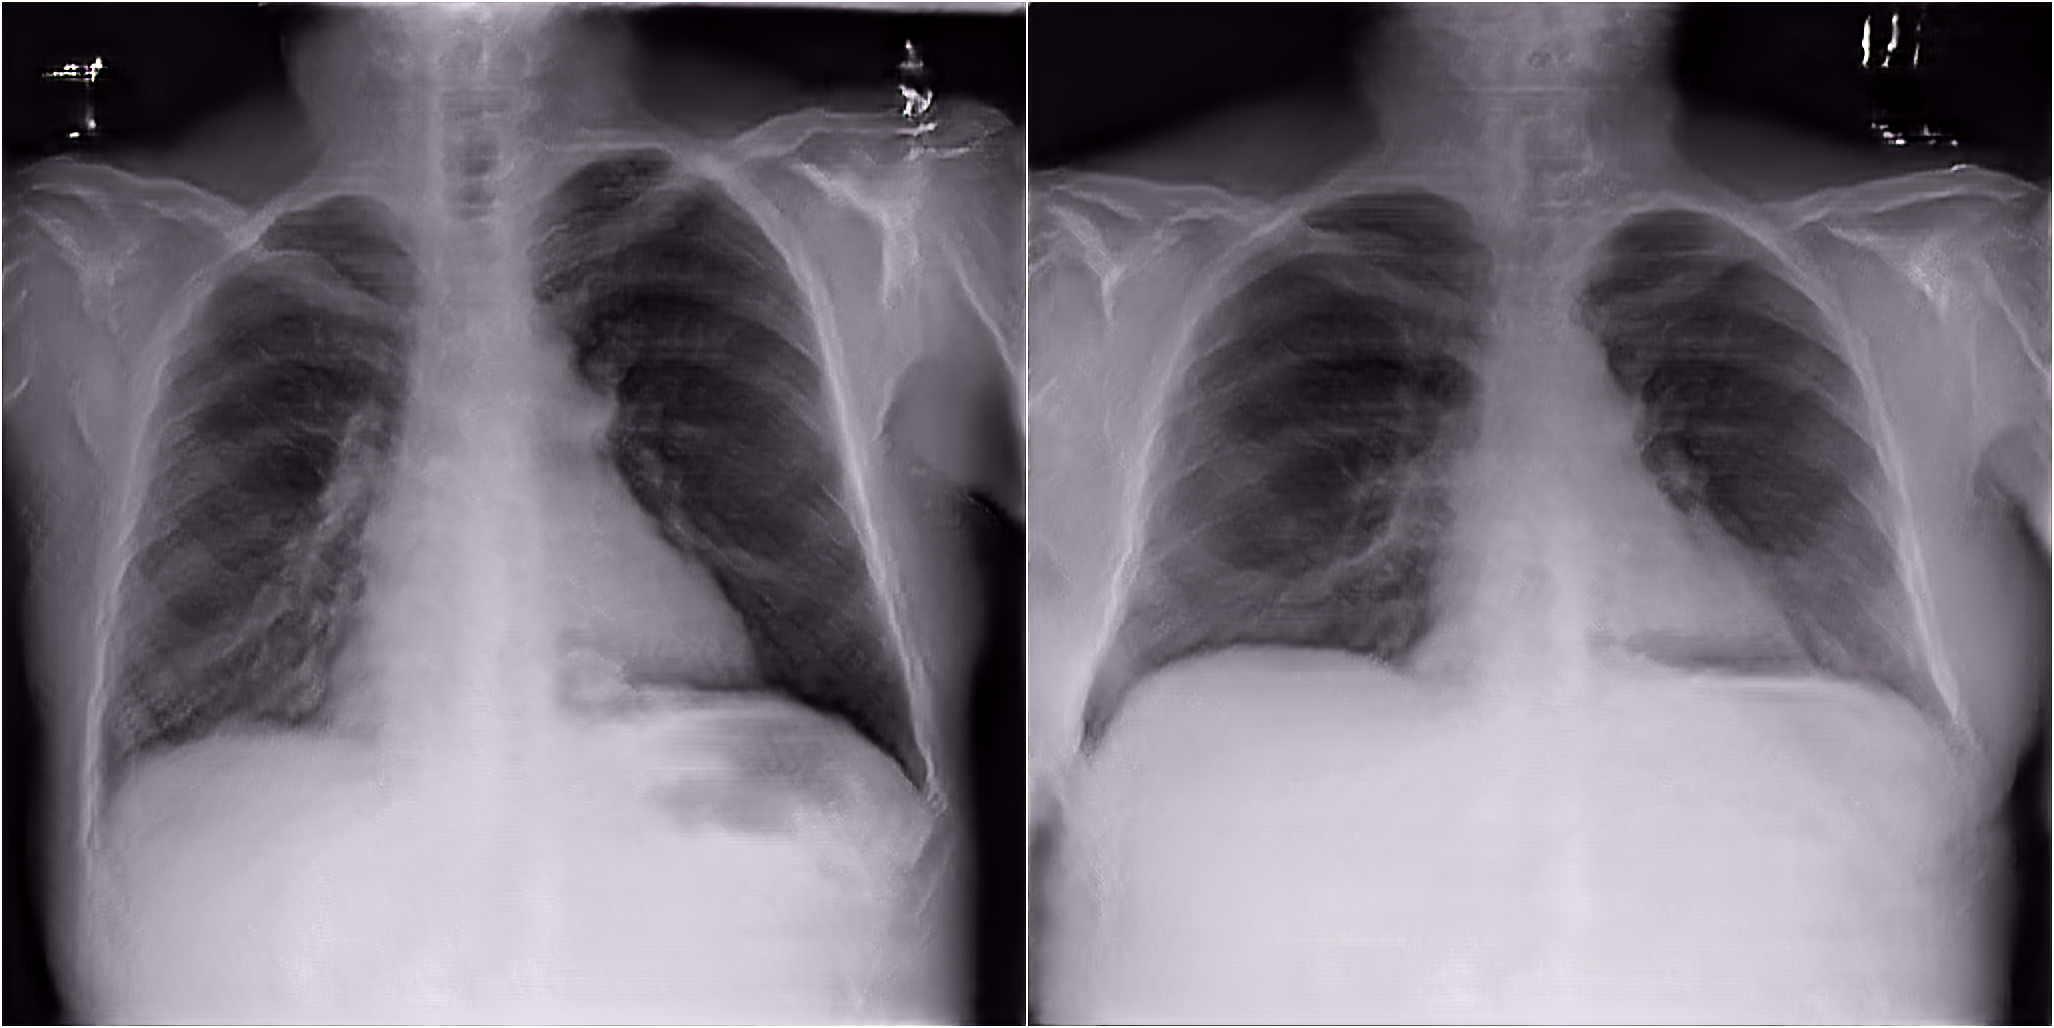

In [52]:
# view_images(sample_dir, num_images=4)
view_images(sample_dir, 2, "*png*")

The images look like chest x-rays. 

The project will work model 10, named `00010_FASTGAN_POLYP_PATCHES_W_MASKS`.

In [21]:
polyp_dir = output_dir / "polyp_samples"
generators.generate(
    model_id=10,
    num_samples=8,
    output_path=polyp_dir,
    install_dependencies=True
)

print(
    f"Created {len(list(polyp_dir.glob('*')))} images (should be twice the number asked for)"
)

100%|██████████| 1/1 [00:05<00:00,  5.26s/it]

Created 16 images (should be twice the number asked for)


This actually generates two kinds of images: the medical image, and a "mask". This is why we have twice the number we asked for, as we get one image and its mask for each sample we ask for. The images are endoscope images of polyps, or growths. Here are sample images generated:

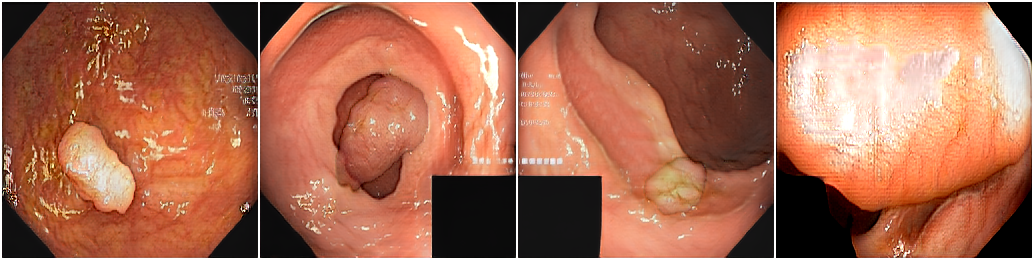

In [53]:
view_images(polyp_dir, 4, "*img*")

The masks mark which parts of the image are polyps. These generally indicate some sort of problem, and we want to be able to detect them. Here are the masks for the images we generated.

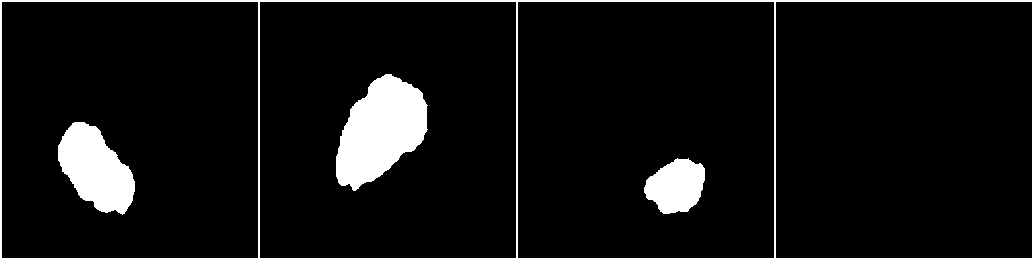

In [54]:
view_images(polyp_dir, 4, "*mask*")

Depending on how your generation went, you could have mostly black images. These would be healthy images, where there was no problem.

**Loading Images**

Medigan has provided us with get_as_torch_dataloader that generates images and sets up a DataLoader:

In [26]:
train_dataloader = generators.get_as_torch_dataloader(
    model_id=10, num_samples=200, batch_size=4, shuffle=True,
    prefetch_factor=None
)

Data loader for validation data:

In [27]:
val_dataloader = generators.get_as_torch_dataloader(
    model_id=10, num_samples=30, batch_size=4, shuffle=False, prefetch_factor=None
)

test_batch = next(iter(val_dataloader))
test_batch_sample = test_batch["sample"]
print(f"Getting batches of shape {test_batch_sample.shape}")

Getting batches of shape torch.Size([4, 256, 256, 3])


Sample data:

Endoscope image shape: torch.Size([256, 256, 3])
Mask image shape: torch.Size([256, 256, 3])

Endoscope


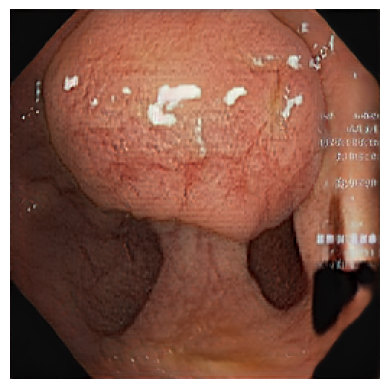

Mask


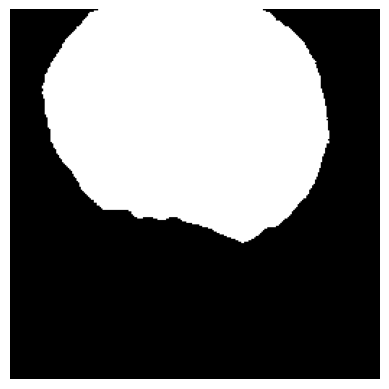

In [28]:
endoscope = test_batch["sample"]
mask = test_batch["mask"]
print(f"Endoscope image shape: {endoscope[0].shape}")
print(f"Mask image shape: {mask[0].shape}")
print()

print("Endoscope")
plt.imshow(endoscope[0])
plt.axis("off")
plt.show()

print("Mask")
plt.imshow(mask[0])
plt.axis("off")
plt.show()

The mask data is only 0 or 1. This will make it a good label for a classifier. Calling the unique method of the mask tensor to verify it only has 0 and 1.

In [29]:
mask.unique()

tensor([0., 1.])

**Training a Model**

The project uses these data loaders to train a model. We'll train a model that detects polyps on endoscope images. We'll use the images as the data, and the mask as the label. This should give us a model that takes in an image, and returns a mask highlighting any polyps. This would be quite useful to the medical industry, to speed up the processing of endoscope results and to double check in case the doctor may have missed something. Our GAN images aren't real data, but they're close enough to get a model doing the right low-level processing.

In [30]:
pretrained_weights = (
    torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
)

model = torchvision.models.segmentation.deeplabv3_resnet50(weights=pretrained_weights)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\Asus/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:33<00:00, 4.99MB/s] 


In [55]:
# print(model)

In [32]:
test_batch_sample.shape

torch.Size([4, 256, 256, 3])

Moving the test_batch_sample to the device:

The shape is a typical image shape of [4, 256, 256, 3], but torch likes tensors of shape [4, 3, 256, 256] (so the channels before the height and width). Also, the model has two outputs: out and aux. We'll only use out.

In [33]:
sample_cuda = test_batch_sample.to(device)

model.to(device)
moved_channel = sample_cuda.permute(0, 3, 1, 2)
result = model(moved_channel)
out = result["out"]

output_shape = out.shape
print(f"Output shape: {output_shape}")

Output shape: torch.Size([4, 21, 256, 256])


We need it to match our mask, which only has one channel. The mask tensor actually has three, but they're all the same, so we'll only use the first one.

In [34]:
print(f"Shape from GAN: {test_batch['mask'].shape}")
print()
moved_channel_mask = test_batch["mask"][:, :, :, :1].permute(0, 3, 1, 2)
print(f"Shape we'll actually use: {moved_channel_mask.shape}")
print()

Shape from GAN: torch.Size([4, 256, 256, 3])

Shape we'll actually use: torch.Size([4, 1, 256, 256])



To minimize the training, only the last layer is replaced/modified.

In [35]:
model.classifier[-1]

Conv2d(256, 21, kernel_size=(1, 1), stride=(1, 1))

The above code shows that the last layer is a convolutional layer that takes `256` channels in and gives `21` channels out. A convolutional layer with a `1 x 1` kernel doesn't change the height or width of the image, but does change the number of channels. Since we're already getting the right height and width, we should only change the number of out channels.

In [36]:
new_final_layer = torch.nn.Conv2d(in_channels=256, out_channels=1,
                                 kernel_size=(1,1))

model.classifier[-1] = new_final_layer

model.to(device)
print(f"New output shape: {model(moved_channel)['out'].shape}")

New output shape: torch.Size([4, 1, 256, 256])


Now, we train the model. 

We need to separate the sample and mask, and change the order from [batch, height, width, channel] to [batch, channel, height, weight]. Also, we can't really compute the "accuracy", since our target isn't a single value, but rather a whole image. We'll only have the loss.

In [37]:
def train_model(
    model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs
):
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for data_dict in tqdm(train_dataloader):
            inputs = data_dict.get("sample")
            masks = data_dict.get("mask")
            # Reorder dimensions to [batch_size, channels, height, width]
            inputs = inputs.permute(0, 3, 1, 2)
            masks = masks.permute(0, 3, 1, 2)
            # Reduce mask to single channel
            masks = masks[:, :1, :, :]

            inputs = inputs.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()

            # Select classifier output
            outputs = model(inputs)["out"]

            # Compute loss and step optimizer
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_dataloader.dataset)
        print(f"Epoch {epoch}/{num_epochs - 1}, Train Loss: {epoch_loss:.4f}")

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for data_dict in tqdm(val_dataloader):
                inputs = data_dict.get("sample")
                masks = data_dict.get("mask")
                inputs = inputs.permute(0, 3, 1, 2)
                masks = masks.permute(0, 3, 1, 2)
                masks = masks[:, :1, :, :]

                inputs = inputs.to(device)
                masks = masks.to(device)

                outputs = model(inputs)["out"]
                loss = criterion(outputs, masks)
                val_loss += loss.item() * inputs.size(0)

        val_epoch_loss = val_loss / len(val_dataloader.dataset)
        print(f"Validation Loss: {val_epoch_loss:.4f}")

Adam optimizer.

In [56]:
# Define loss function and optimizer
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0001)

print(
    f"Created optimizer of type {type(optimizer)} with learning rate {optimizer.defaults['lr']}"
)

Created optimizer of type <class 'torch.optim.adam.Adam'> with learning rate 0.0001


In [57]:
train_model(model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs=2)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0/1, Train Loss: 0.4231


  0%|          | 0/8 [00:00<?, ?it/s]

Validation Loss: 0.2488


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/1, Train Loss: 0.2508


  0%|          | 0/8 [00:00<?, ?it/s]

Validation Loss: 0.2133


Loading pre-trained model

In [59]:
model_state = torch.load("polyp_model.pth",  map_location=torch.device('cpu'))

# Load the state dictionary that has trained weights
model.load_state_dict(model_state)

<All keys matched successfully>

**Testing our Model**

In [60]:
test_dataloader = generators.get_as_torch_dataloader(
    model_id=10, num_samples=20, batch_size=4, 
    shuffle=False, prefetch_factor=None
)

final_test_batch = next(iter(test_dataloader))
final_test_sample = final_test_batch["sample"]
final_test_mask = final_test_batch["mask"]

print(f"Test sample image shape: {final_test_sample.shape}")
print(f"Test mask image shape: {final_test_mask.shape}")

Test sample image shape: torch.Size([4, 256, 256, 3])
Test mask image shape: torch.Size([4, 256, 256, 3])


Running the Model:

In [61]:
# Permute the channel to the right place
final_moved_channels = final_test_sample.permute(0, 3, 1, 2)

# Move to the device 
final_moved_channels_cuda = final_moved_channels.to(device)

# Run the model
final_model_result = model(final_moved_channels_cuda)

# Select the out part of the result
final_out = final_model_result['out']

# Move the channel back to the last position so we can display the image
final_classifier_out = final_out.permute(0, 2, 3, 1)

print(f"Final images shape {final_classifier_out.shape}")

Final images shape torch.Size([4, 256, 256, 1])


In [ ]:
print("Getting range:")
final_classifier_out.min().item(), final_classifier_out.max().item()

We can repair that by running the result through a sigmoid function, which will ensure every value is between 0 amd 1.

In [ ]:
final_classifier_image = torch.sigmoid(final_classifier_out)

Plotting the results:

In [ ]:
def plot_images_from_tensor(tensor):
    grid = make_grid(tensor.permute(0, 3, 1, 2), nrow=4, pad_value=1.0)
    return torchvision.transforms.ToPILImage()(grid)

In [ ]:
plot_images_from_tensor(final_test_sample)

In [ ]:
plot_images_from_tensor(final_test_mask)

In [ ]:
plot_images_from_tensor(final_classifier_image)